# A Systemic Risk Framework for the Vietnamese Market: a Composite Risk Index and Financial Stress Prediction

## 1. Collect the Data

Import the needed libraries.

In [1]:
import requests
import pandas as pd
from functools import reduce
import io
import time
import yfinance as yf
try:
  import akshare as ak
except:
  !pip install akshare
  import akshare as ak
from concurrent.futures import ThreadPoolExecutor, as_completed
from google.colab import drive
from google.colab import files
import os

Build a Data Information Table for the Vietnamese equity data, including:
- Ticker;
- Company Name;
- Sector: the industry the company operates in;
- Risk Transmission Channel: a macro-economic sector that represents a specific source or amplifier of shocks, spreading systemic risk within and across sectors.

In [2]:
ticker_info = {
    "NT2": {"Risk Transmission Channel": "Energy & Infrastructure", "Sector": "Energy", "Company": "PetroVietnam Power Nhon Trach 2 JSC"},
    "PVD": {"Risk Transmission Channel": "Energy & Infrastructure", "Sector": "Energy", "Company": "PetroVietnam Drilling & Well Services Corp"},
    "PVS": {"Risk Transmission Channel": "Energy & Infrastructure", "Sector": "Energy", "Company": "PetroVietnam Technical Services Corp"},
    "PVT": {"Risk Transmission Channel": "Energy & Infrastructure", "Sector": "Energy", "Company": "PetroVietnam Transportation Corp"},
    "REE": {"Risk Transmission Channel": "Energy & Infrastructure", "Sector": "Utilities / Infrastructure", "Company": "Refrigeration Electrical Engineering Corp"},
    "ACB": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Banking", "Company": "Asia Commercial Joint Stock Bank"},
    "CTG": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Banking", "Company": "VietinBank"},
    "MBB": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Banking", "Company": "Military Commercial JSB"},
    "SHB": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Banking", "Company": "Saigon-Hanoi Commercial JSB"},
    "STB": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Banking", "Company": "Saigon Thuong Tin Commercial JSB"},
    "VCB": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Banking", "Company": "Vietcombank"},
    "BVH": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Insurance", "Company": "Bao Viet Holdings"},
    "PVI": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Insurance", "Company": "PVI Holdings"},
    "SSI": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Securities/Brokerage", "Company": "SSI Securities Corp"},
    "VIX": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Securities/Brokerage", "Company": "VIX Securities JSC"},
    "VND": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Securities/Brokerage", "Company": "VNDirect Securities Corp"},
    "GMD": {"Risk Transmission Channel": "Logistics", "Sector": "Logistics", "Company": "Gemadept Corp"},
    "VSC": {"Risk Transmission Channel": "Logistics", "Sector": "Logistics", "Company": "Vietnam Container Shipping JSC"},
    "MSN": {"Risk Transmission Channel": "Real Economy", "Sector": "Consumer Goods / Retail", "Company": "Masan Group Corp"},
    "PNJ": {"Risk Transmission Channel": "Real Economy", "Sector": "Consumer Goods / Retail", "Company": "Phu Nhuan Jewelry JSC"},
    "VNM": {"Risk Transmission Channel": "Real Economy", "Sector": "Consumer Goods / Retail", "Company": "Vietnam Dairy Products JSC"},
    "CSM": {"Risk Transmission Channel": "Real Economy", "Sector": "Industrial / Materials", "Company": "Casumina"},
    "DPM": {"Risk Transmission Channel": "Real Economy", "Sector": "Industrial / Materials", "Company": "PetroVietnam Fertilizer and Chemicals Corp"},
    "HPG": {"Risk Transmission Channel": "Real Economy", "Sector": "Materials / Industrial", "Company": "Hoa Phat Group JSC"},
    "HSG": {"Risk Transmission Channel": "Real Economy", "Sector": "Materials / Industrial", "Company": "Hoa Sen Group"},
    "NKG": {"Risk Transmission Channel": "Real Economy", "Sector": "Materials / Industrial", "Company": "Nam Kim Steel JSC"},
    "FPT": {"Risk Transmission Channel": "Real Economy", "Sector": "Technology", "Company": "FPT Corp"},
    "DIG": {"Risk Transmission Channel": "Real Estate", "Sector": "Real Estate", "Company": "Development Investment Construction JSC"},
    "DXG": {"Risk Transmission Channel": "Real Estate", "Sector": "Real Estate", "Company": "Dat Xanh Group JSC"},
    "KBC": {"Risk Transmission Channel": "Real Estate", "Sector": "Real Estate", "Company": "Kinh Bac City Development Holding Corp"},
    "KDH": {"Risk Transmission Channel": "Real Estate", "Sector": "Real Estate", "Company": "Khang Dien House Trading and Investment JSC"},
    "VIC": {"Risk Transmission Channel": "Real Estate", "Sector": "Real Estate", "Company": "Vingroup JSC"},
}
ticker_df = (
    pd.DataFrame.from_dict(ticker_info, orient="index")
      .reset_index()
      .rename(columns={"index": "ticker"})
      [["Risk Transmission Channel", "Sector", "Company", "ticker"]]
)

ticker_df

,Risk Transmission Channel,Sector,Company,ticker
0,Energy & Infrastructure,Energy,PetroVietnam Power Nhon Trach 2 JSC,NT2
1,Energy & Infrastructure,Energy,PetroVietnam Drilling & Well Services Corp,PVD
2,Energy & Infrastructure,Energy,PetroVietnam Technical Services Corp,PVS
3,Energy & Infrastructure,Energy,PetroVietnam Transportation Corp,PVT
4,Energy & Infrastructure,Utilities / Infrastructure,Refrigeration Electrical Engineering Corp,REE
5,Financial System,Finance - Banking,Asia Commercial Joint Stock Bank,ACB
6,Financial System,Finance - Banking,VietinBank,CTG
7,Financial System,Finance - Banking,Military Commercial JSB,MBB
8,Financial System,Finance - Banking,Saigon-Hanoi Commercial JSB,SHB
9,Financial System,Finance - Banking,Saigon Thuong Tin Commercial JSB,STB


Build a function to collect Vietnamese stock data from <a href='https://cafef.vn/'>CafeF</a>.

In [3]:
session = requests.Session()
headers = {"User-Agent": "Mozilla/5.0", "Referer": "https://cafef.vn/", "Origin": "https://cafef.vn", "X-Requested-With": "XMLHttpRequest",}

def fetch_price_history_cafef(ticker, start="2012-01-01", end="2026-03-31"):
  url = "https://cafef.vn/du-lieu/Ajax/PageNew/DataHistory/PriceHistory.ashx"

  all_data = []
  page = 1

  while True:
    params = {"Symbol":ticker,"StartDate":"","EndDate":"","PageIndex":page,"PageSize":100}

    try:
      r = session.get(url, headers=headers, params=params, timeout=15)
      r.raise_for_status()
      json_data = r.json()
    except Exception as e:
      print(f"{ticker}: request failed -> {e}")
      break

    if not json_data or json_data.get("Data") is None:
      print(f"{ticker}: no data returned (page {page})")
      break

    data = json_data["Data"].get("Data", [])

    if not data:
      break

    all_data.extend(data)

    # stop if last page
    if len(data) < 100:
      break

    page += 1
    time.sleep(0.1)  # avoid throttling

  if not all_data:
    print(f"{ticker}: EMPTY")
    return pd.DataFrame(columns=["Date", f"{ticker}_close", f"{ticker}_volume"])

  df = pd.DataFrame(all_data).rename(columns={"Ngay": "Date","GiaDieuChinh": f"{ticker}_close","KhoiLuongKhopLenh": f"{ticker}_volume"})

  df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
  df[f"{ticker}_close"] = pd.to_numeric(df[f"{ticker}_close"], errors="coerce")
  df[f"{ticker}_volume"] = pd.to_numeric(df[f"{ticker}_volume"], errors="coerce")
  start_dt = pd.to_datetime(start, format="%Y-%m-%d")
  end_dt = pd.to_datetime(end, format="%Y-%m-%d")
  df = df[(df["Date"] >= start_dt) & (df["Date"] <= end_dt)]

  return df[["Date", f"{ticker}_close", f"{ticker}_volume"]]

Collect the Vietnamese equity data from <a href='https://cafef.vn/'>CafeF.</a>

```python
def fetch_wrapper(t):
    print(f"Fetching {t}...")
    df = fetch_price_history_cafef(t)
    return t, df

dfs = []

with ThreadPoolExecutor(max_workers=5) as executor:
    futures = [executor.submit(fetch_wrapper, t) for t in ticker_info.keys()]

    for future in as_completed(futures):
        t, df = future.result()
        if not df.empty:
            dfs.append(df)
        else:
            print(f"{t}: dropped")
```
Fetching NT2...  
Fetching PVD...  
Fetching PVS...  
Fetching PVT...  
Fetching REE...  
Fetching ACB...  
Fetching CTG...  
Fetching MBB...  
Fetching SHB...  
Fetching STB...  
Fetching VCB...  
Fetching BVH...  
Fetching PVI...  
Fetching SSI...  
Fetching VIX...  
Fetching VND...  
Fetching GMD...  
Fetching VSC...  
Fetching MSN...  
Fetching PNJ...  
Fetching VNM...  
Fetching CSM...  
Fetching DPM...  
Fetching HPG...  
Fetching HSG...  
Fetching NKG...  
Fetching FPT...  
Fetching DIG...  
Fetching DXG...  
Fetching KBC...  
Fetching KDH...  
Fetching VIC...  

Save the dataframe to avoid fetching the data from <a href='https://cafef.vn/'>CafeF</a> again.

```python
df_vn = reduce(lambda left, right: pd.merge(left, right, on="Date", how="outer"),dfs)
df_vn = df_vn.sort_values("Date").reset_index(drop=True)
df_vn.to_csv("df_vn.csv", index=False)  # saves in VM
files.download("df_vn.csv")
df_vn.to_parquet("df_vn.parquet", index=False)
files.download("df_vn.parquet")
```

Import the dataframe to the notebook.

In [4]:
file_path = "/content/drive/My Drive/WQU/10_Capstone_Project/Capstone Project/data/df_vn.parquet"
def import_data(file_path):
  try:
    drive.mount('/content/drive', force_remount=True)
    # Check if file exists
    if os.path.exists(file_path):
      df = pd.read_parquet(file_path)
      print(f"Loaded dataframe from Drive ({file_path})")
    else:
      raise FileNotFoundError(f"File not found at {file_path}")

  except Exception as e:
    print(f"Drive not available or file missing: {e}")
    print("Please upload dataframe manually.")
    uploaded = files.upload()

    # Automatically read the uploaded file
    file_name = list(uploaded.keys())[0]  # pick the first uploaded file
    df = pd.read_parquet(io.BytesIO(uploaded[file_name]))
    print(f"Loaded {file_name} from manual upload")
    return df

In [5]:
df_vn = import_data(file_path)

Drive not available or file missing: Error: credential propagation was unsuccessful
Please upload dataframe manually.


Saving df_vn.parquet to df_vn (2).parquet
Loaded df_vn (2).parquet from manual upload


In [6]:
df_vn.head()

,Date,NT2_close,NT2_volume,PVT_close,PVT_volume,PVS_close,PVS_volume,PVD_close,PVD_volume,REE_close,...,DIG_close,DIG_volume,DXG_close,DXG_volume,KBC_close,KBC_volume,KDH_close,KDH_volume,VIC_close,VIC_volume
0,2012-01-03,1.06,16500.0,1.01,33120.0,3.73,77900.0,13.42,40680.0,2.77,...,2.04,105040.0,1.17,30690.0,4.96,315520.0,3.60,55300.0,7.81,39190.0
1,2012-01-04,1.06,12000.0,1.04,457630.0,3.50,285700.0,12.79,97220.0,2.85,...,2.00,142770.0,1.15,28520.0,5.01,70540.0,3.73,61980.0,7.85,38760.0
2,2012-01-05,0.97,0.0,1.07,621160.0,3.42,446500.0,12.74,66780.0,2.85,...,1.96,66330.0,1.13,33310.0,4.91,43340.0,3.90,52010.0,7.49,15860.0
3,2012-01-06,1.06,2900.0,1.04,282320.0,3.34,94100.0,12.74,15050.0,2.80,...,1.91,242390.0,1.12,13890.0,4.91,29410.0,3.86,37940.0,7.45,22080.0
4,2012-01-09,1.10,1100.0,1.04,231330.0,3.29,125400.0,12.58,31050.0,2.90,...,1.85,630070.0,1.10,6770.0,4.82,59880.0,3.81,53980.0,7.81,14940.0


In [7]:
df_vn.tail()

,Date,NT2_close,NT2_volume,PVT_close,PVT_volume,PVS_close,PVS_volume,PVD_close,PVD_volume,REE_close,...,DIG_close,DIG_volume,DXG_close,DXG_volume,KBC_close,KBC_volume,KDH_close,KDH_volume,VIC_close,VIC_volume
3547,2026-03-25,27.70,2979600.0,21.70,8810800.0,42.2,7282100.0,34.75,3336600.0,70.9,...,13.80,11696900.0,14.15,20550300.0,28.9,4274000.0,25.85,5073300.0,128.7,3013400.0
3548,2026-03-26,27.75,1455700.0,22.40,13267800.0,42.0,5057500.0,34.70,4219300.0,71.7,...,13.55,8624500.0,13.85,15497700.0,28.7,1780000.0,25.45,2692100.0,130.0,2435600.0
3549,2026-03-27,27.90,950600.0,22.30,9317400.0,42.8,5938400.0,35.75,5186400.0,71.7,...,14.45,24713800.0,14.60,41747300.0,30.7,6091600.0,26.40,4704200.0,132.6,2124700.0
3550,2026-03-30,27.90,1371700.0,21.85,12201400.0,42.8,5262900.0,36.20,4041300.0,70.0,...,14.20,13413500.0,14.30,16998400.0,31.8,7130700.0,26.05,4370900.0,129.5,2042500.0
3551,2026-03-31,27.60,846800.0,21.80,7238400.0,40.9,7568200.0,34.80,5738900.0,68.5,...,14.25,11416400.0,14.55,21018600.0,31.9,2270100.0,26.00,4193600.0,135.0,3316700.0


In [8]:
df_vn.shape

(3552, 65)

___

Gather VNIndex historical data (source: <a href='https://cafef.vn/'>CafeF</a>).

```python
df_vnindex = fetch_price_history_cafef("VNINDEX", start="2012-01-01", end="2026-03-31")
df_vnindex = df_vnindex.sort_values("Date").reset_index(drop=True)
```

Collect data for external financial markets: advanced and regionally dominant economies (sources: <a href='https://finance.yahoo.com/'>Yahoo Finance</a> and <a href='https://github.com/akfamily/akshare'>AKShare</a>).

```python
foreign_index = {
    "^GSPC": "S&P 500 (US)",
    "^GSPTSE": "S&P/TSX (Canada)",
    "^STOXX50E": "EURO STOXX 50 (EU)",
    "^FTSE": "FTSE 100 (UK)",
    # "000300.SS": "CSI 300 (China)",
    "^N225": "Nikkei 225 (Japan)",
    "^KS11": "KOSPI (S.Korea)",
    "^AXJO": "S&P/ASX 200 (Australia)",
    "^HSI": "Hang Seng (HK)",
    "^TWII": "TWSE (Taiwan)"
}
foreign_index.keys()
df_fx = yf.download(list(foreign_index.keys()), start="2012-01-01", end="2026-04-01", auto_adjust= True)[['Close']]#, 'Volume']]

df_fx.columns =  [f"{ticker}_{level}" for level, ticker in df_fx.columns]
```

```python
df_CSI300= (
    ak.stock_zh_index_daily(symbol="sh000300")
      .assign(date=lambda x: pd.to_datetime(x["date"]))
      .set_index("date")
      .loc["2012-01-01":"2026-03-31", ["close"]]#, "volume"]]
      .rename_axis(None)
      .rename(columns={"close": "CSI300_close"})#, "volume": "CSI300_volume"})
      .reset_index()
      .rename(columns={"index": "Date", "date": "Date"})
      .set_index("Date")
)
```

```python
# combine all international data
df_glob = (df_vnindex.merge(df_fx, on="Date", how="outer").merge(df_CSI300, on="Date", how="outer").sort_values("Date").reset_index(drop=True)).drop(['VNINDEX_volume'], axis=1)
```

Save the dataframe with the international indexes on the Drive.

```python
df_glob.to_csv("df_glob.csv", index=False)
files.download("df_glob.csv")
df_glob.to_parquet("df_glob.parquet", index=False)
files.download("df_glob.parquet")
```

Import the dataframe with the international data to the notebook.

In [9]:
file_path = "/content/drive/My Drive/WQU/10_Capstone_Project/Capstone Project/data/df_glob.parquet"
df_glob = import_data(file_path)

Drive not available or file missing: Error: credential propagation was unsuccessful
Please upload dataframe manually.


Saving df_glob.parquet to df_glob (2).parquet
Loaded df_glob (2).parquet from manual upload


In [10]:
df_glob.head()

,Date,VNINDEX_close,^AXJO_Close,^FTSE_Close,^GSPC_Close,^GSPTSE_Close,^HSI_Close,^KS11_Close,^N225_Close,^STOXX50E_Close,^TWII_Close,CSI300_close
0,2012-01-02,NaN,NaN,NaN,NaN,NaN,NaN,1826.369995,NaN,NaN,NaN,NaN
1,2012-01-03,350.00,4101.200195,5699.899902,1277.060059,12208.400391,18877.410156,1875.410034,NaN,2389.909912,7053.348145,NaN
2,2012-01-04,348.84,4187.799805,5668.500000,1277.300049,12226.500000,18727.310547,1866.219971,8560.110352,2349.889893,7082.937988,2298.753
3,2012-01-05,340.94,4142.700195,5624.299805,1281.060059,12237.400391,18813.410156,1863.739990,8488.709961,2315.750000,7130.827148,2276.385
4,2012-01-06,336.73,4108.500000,5649.700195,1277.810059,12188.599609,18593.060547,1843.140015,8390.349609,2298.649902,7120.477051,2290.601


In [11]:
df_glob.tail()

,Date,VNINDEX_close,^AXJO_Close,^FTSE_Close,^GSPC_Close,^GSPTSE_Close,^HSI_Close,^KS11_Close,^N225_Close,^STOXX50E_Close,^TWII_Close,CSI300_close
3701,2026-03-25,1658.19,8557.599609,10106.799805,6591.899902,32382.599609,25335.949219,5642.209961,53749.621094,5649.330078,33439.109375,4537.466
3702,2026-03-26,1644.63,8525.700195,9972.200195,6477.160156,31887.500000,24856.429688,5460.459961,53603.648438,5565.930176,33337.621094,4477.534
3703,2026-03-27,1672.80,8516.299805,9967.400391,6368.850098,31960.699219,24951.880859,5438.870117,53373.070312,5505.799805,33112.589844,4502.570
3704,2026-03-30,1662.54,8461.000000,10128.000000,6343.720215,31934.900391,24750.789062,5277.299805,51885.851562,5541.790039,32518.160156,4491.950
3705,2026-03-31,1674.49,8481.799805,10176.500000,6528.520020,32768.000000,24788.140625,5052.459961,51063.718750,5569.729980,31722.990234,4450.049


In [12]:
df_glob.shape

(3706, 12)

## 2. Data Cleaning and Exploratory Data Analysis

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
try:
  from arch.unitroot import ADF
except:
  !pip install arch
  from arch.unitroot import ADF

### 2.1. Domestic Data

In [14]:
# Create a dataframe with the closing prices and with date column as index
df_price = df_vn.set_index('Date')[df_vn.columns[df_vn.columns.str.endswith('_close')]]
df_price = df_price*1000 #Cafef Data in thousand VND
df_price

,NT2_close,PVT_close,PVS_close,PVD_close,REE_close,MBB_close,CTG_close,ACB_close,SHB_close,STB_close,...,DPM_close,HPG_close,HSG_close,NKG_close,FPT_close,DIG_close,DXG_close,KBC_close,KDH_close,VIC_close
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-03,1060.0,1010.0,3730.0,13420.0,2770.0,1350.0,4120.0,2660.0,1050.0,8460.0,...,3400.0,620.0,880.0,1990.0,4040.0,2040.0,1170.0,4960.0,3600.0,7810.0
2012-01-04,1060.0,1040.0,3500.0,12790.0,2850.0,1350.0,4310.0,2700.0,1040.0,8730.0,...,3340.0,610.0,860.0,1910.0,4040.0,2000.0,1150.0,5010.0,3730.0,7850.0
2012-01-05,970.0,1070.0,3420.0,12740.0,2850.0,1320.0,4290.0,2750.0,1020.0,8620.0,...,3290.0,590.0,850.0,1920.0,3950.0,1960.0,1130.0,4910.0,3900.0,7490.0
2012-01-06,1060.0,1040.0,3340.0,12740.0,2800.0,1320.0,4360.0,2740.0,1020.0,8730.0,...,3260.0,570.0,840.0,1940.0,3990.0,1910.0,1120.0,4910.0,3860.0,7450.0
2012-01-09,1100.0,1040.0,3290.0,12580.0,2900.0,1340.0,4390.0,2720.0,1020.0,9160.0,...,3340.0,570.0,860.0,1940.0,4000.0,1850.0,1100.0,4820.0,3810.0,7810.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,27700.0,21700.0,42200.0,34750.0,70900.0,26000.0,34050.0,23800.0,13080.0,62200.0,...,29400.0,26350.0,14400.0,13400.0,77000.0,13800.0,14150.0,28900.0,25850.0,128700.0
2026-03-26,27750.0,22400.0,42000.0,34700.0,71700.0,25800.0,33800.0,23600.0,13210.0,60600.0,...,31100.0,25900.0,14500.0,13350.0,74200.0,13550.0,13850.0,28700.0,25450.0,130000.0
2026-03-27,27900.0,22300.0,42800.0,35750.0,71700.0,26150.0,34800.0,23800.0,13430.0,59900.0,...,30800.0,26500.0,14900.0,13800.0,76100.0,14450.0,14600.0,30700.0,26400.0,132600.0


In [15]:
# Create a dataframe with the trading volumes and with date column as index
df_vn_vol = df_vn.set_index('Date')[df_vn.columns[df_vn.columns.str.endswith('_volume')]]
df_vn_vol

,NT2_volume,PVT_volume,PVS_volume,PVD_volume,REE_volume,MBB_volume,CTG_volume,ACB_volume,SHB_volume,STB_volume,...,DPM_volume,HPG_volume,HSG_volume,NKG_volume,FPT_volume,DIG_volume,DXG_volume,KBC_volume,KDH_volume,VIC_volume
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-03,16500.0,33120.0,77900.0,40680.0,259370.0,462000.0,147320.0,27200.0,384400.0,957240.0,...,215580.0,57960.0,101880.0,6890.0,74810.0,105040.0,30690.0,315520.0,55300.0,39190.0
2012-01-04,12000.0,457630.0,285700.0,97220.0,502250.0,368740.0,294380.0,224200.0,264900.0,2845110.0,...,96730.0,27520.0,110970.0,5100.0,29710.0,142770.0,28520.0,70540.0,61980.0,38760.0
2012-01-05,0.0,621160.0,446500.0,66780.0,407690.0,478490.0,194610.0,344100.0,411200.0,1813900.0,...,186030.0,345840.0,134270.0,4060.0,64890.0,66330.0,33310.0,43340.0,52010.0,15860.0
2012-01-06,2900.0,282320.0,94100.0,15050.0,250620.0,331370.0,330690.0,233100.0,209600.0,3081380.0,...,166820.0,474620.0,245600.0,120860.0,66090.0,242390.0,13890.0,29410.0,37940.0,22080.0
2012-01-09,1100.0,231330.0,125400.0,31050.0,536720.0,464800.0,109050.0,123000.0,517500.0,3524980.0,...,152650.0,187210.0,80650.0,22430.0,46080.0,630070.0,6770.0,59880.0,53980.0,14940.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,2979600.0,8810800.0,7282100.0,3336600.0,3852100.0,13825500.0,6241100.0,12449400.0,76541900.0,5688900.0,...,5732000.0,22967100.0,4120300.0,2834500.0,7429300.0,11696900.0,20550300.0,4274000.0,5073300.0,3013400.0
2026-03-26,1455700.0,13267800.0,5057500.0,4219300.0,2072000.0,13683600.0,5738200.0,8294500.0,67867100.0,5034300.0,...,12313800.0,18424200.0,2034500.0,3367400.0,9743400.0,8624500.0,15497700.0,1780000.0,2692100.0,2435600.0
2026-03-27,950600.0,9317400.0,5938400.0,5186400.0,1678800.0,12866700.0,12073500.0,7638400.0,69844300.0,9368300.0,...,9590700.0,26863700.0,3746700.0,3679600.0,9080300.0,24713800.0,41747300.0,6091600.0,4704200.0,2124700.0


In [16]:
# Check for missing data
for c in df_vn.columns[1:]:
  miss_prc = df_vn[c].isnull().sum()
  miss_vol = df_vn[c].isnull().sum()

  print('Missing Price in {} column:'.format(c), miss_prc)
  print('Missing Trading Volume in {} column:'.format(c), miss_vol)
  print('')

Missing Price in NT2_close column: 55
Missing Trading Volume in NT2_close column: 55

Missing Price in NT2_volume column: 55
Missing Trading Volume in NT2_volume column: 55

Missing Price in PVT_close column: 2
Missing Trading Volume in PVT_close column: 2

Missing Price in PVT_volume column: 2
Missing Trading Volume in PVT_volume column: 2

Missing Price in PVS_close column: 17
Missing Trading Volume in PVS_close column: 17

Missing Price in PVS_volume column: 17
Missing Trading Volume in PVS_volume column: 17

Missing Price in PVD_close column: 2
Missing Trading Volume in PVD_close column: 2

Missing Price in PVD_volume column: 2
Missing Trading Volume in PVD_volume column: 2

Missing Price in REE_close column: 2
Missing Trading Volume in REE_close column: 2

Missing Price in REE_volume column: 2
Missing Trading Volume in REE_volume column: 2

Missing Price in MBB_close column: 2
Missing Trading Volume in MBB_close column: 2

Missing Price in MBB_volume column: 2
Missing Trading Volu

In [17]:
# Deal with mising values for Price database: apply NaN Forward fill by propagating the last valid observation to next valid.
df_price.ffill(inplace=True)
# Deal with mising values for Tradinng Volume database: set missing value to 0.
df_vn_vol = df_vn_vol.fillna(0)

In [18]:
# Calculate log returns for Vietnamese stocks
df_vn_ret = np.log(df_price/df_price.shift(1))
df_vn_ret = df_vn_ret.dropna()
df_vn_ret.columns = df_vn_ret.columns.str.replace('_close', '', regex=False)
df_vn_ret

,NT2,PVT,PVS,PVD,REE,MBB,CTG,ACB,SHB,STB,...,DPM,HPG,HSG,NKG,FPT,DIG,DXG,KBC,KDH,VIC
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-04,0.000000,0.029270,-0.063645,-0.048083,0.028472,0.000000,0.045085,0.014926,-0.009569,0.031416,...,-0.017805,-0.016261,-0.022990,-0.041031,0.000000,-0.019803,-0.017242,0.010030,0.035474,0.005109
2012-01-05,-0.088728,0.028438,-0.023122,-0.003917,0.000000,-0.022473,-0.004651,0.018349,-0.019418,-0.012680,...,-0.015083,-0.033336,-0.011696,0.005222,-0.022529,-0.020203,-0.017544,-0.020162,0.044568,-0.046945
2012-01-06,0.088728,-0.028438,-0.023670,0.000000,-0.017700,0.000000,0.016185,-0.003643,0.000000,0.012680,...,-0.009160,-0.034486,-0.011834,0.010363,0.010076,-0.025841,-0.008889,0.000000,-0.010309,-0.005355
2012-01-09,0.037041,0.000000,-0.015083,-0.012638,0.035091,0.015038,0.006857,-0.007326,0.000000,0.048081,...,0.024244,0.000000,0.023530,0.000000,0.002503,-0.031918,-0.018019,-0.018500,-0.013038,0.047191
2012-01-10,0.000000,0.028438,0.006061,0.028988,0.023851,0.014815,0.031393,0.007326,0.028988,0.035392,...,0.023670,0.000000,0.022990,0.000000,0.014889,-0.010870,0.044452,0.028632,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,0.067189,0.023311,0.028848,0.036634,0.067081,0.015504,0.014793,0.029853,0.037388,0.022765,...,0.020619,0.015297,0.003478,0.018833,0.020998,0.021979,0.032319,0.044216,0.033435,0.037203
2026-03-26,0.001803,0.031749,-0.004751,-0.001440,0.011220,-0.007722,-0.007369,-0.008439,0.009890,-0.026060,...,0.056213,-0.017225,0.006920,-0.003738,-0.037041,-0.018282,-0.021429,-0.006944,-0.015595,0.010050
2026-03-27,0.005391,-0.004474,0.018868,0.029811,0.000000,0.013475,0.029157,0.008439,0.016517,-0.011618,...,-0.009693,0.022902,0.027213,0.033152,0.025284,0.064308,0.052736,0.067366,0.036648,0.019803


In [19]:
# EDA: Descriptive Stats for log returns data
df_vn_ret.describe()

,NT2,PVT,PVS,PVD,REE,MBB,CTG,ACB,SHB,STB,...,DPM,HPG,HSG,NKG,FPT,DIG,DXG,KBC,KDH,VIC
count,3551.000000,3551.000000,3551.000000,3551.000000,3551.000000,3551.000000,3551.000000,3551.000000,3551.000000,3551.000000,...,3551.000000,3551.000000,3551.000000,3551.000000,3551.000000,3551.000000,3551.000000,3551.000000,3551.000000,3551.000000
mean,0.000918,0.000865,0.000674,0.000268,0.000903,0.000838,0.000599,0.000614,0.000720,0.000562,...,0.000612,0.001062,0.000796,0.000546,0.000822,0.000547,0.000710,0.000524,0.000557,0.000803
std,0.024863,0.024985,0.028168,0.027077,0.019781,0.019563,0.021388,0.017852,0.025390,0.022690,...,0.021158,0.024526,0.031411,0.030781,0.020928,0.029427,0.029673,0.026831,0.021973,0.021628
min,-0.114709,-0.079396,-0.105617,-0.088255,-0.115069,-0.200397,-0.202524,-0.119893,-0.158870,-0.072539,...,-0.073347,-0.289234,-0.470900,-0.285019,-0.237532,-0.092950,-0.145301,-0.073122,-0.220654,-0.308547
25%,-0.008618,-0.012092,-0.012284,-0.013906,-0.008730,-0.007744,-0.009557,-0.006849,-0.012513,-0.010084,...,-0.008969,-0.010000,-0.013354,-0.014095,-0.007282,-0.014675,-0.014865,-0.013011,-0.008196,-0.007402
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.009538,0.013908,0.014062,0.014840,0.009859,0.008933,0.010022,0.007942,0.012195,0.010508,...,0.010326,0.011561,0.014591,0.015019,0.008719,0.016078,0.017264,0.013819,0.008960,0.007643
max,0.119238,0.102195,0.333844,0.153372,0.145147,0.198735,0.221728,0.186218,0.174072,0.134304,...,0.105988,0.356414,0.554311,0.380275,0.227362,0.162768,0.217168,0.364487,0.226854,0.287682


Median is 0 for all stocks and the mean is also very close to 0, which means returns are centered around 0 with no (or close to 0) drift.

In [20]:
# EDA: Skeweness
df_vn_ret.skew()

,0
NT2,0.139170
PVT,-0.005301
PVS,0.256135
PVD,-0.057371
REE,0.194848
MBB,0.080173
CTG,-0.004417
ACB,0.046077
SHB,0.163524
STB,0.102263


In [21]:
print('Average Skewness-full sample:', df_vn_ret.skew().mean())

Average Skewness-full sample: 0.5111172153382306


Returns are approximately symmetric, with few exhibiting a positive long tail (skewness greater than 1): VietcomBank (VCB), Vinamilk (VNM), and especially VNDirect Securities (VND).

In [22]:
# EDA: Kurtosis
df_vn_ret.kurt()

,0
NT2,3.788417
PVT,1.104420
PVS,8.052469
PVD,1.093367
REE,5.309676
MBB,11.404131
CTG,7.573677
ACB,8.218072
SHB,3.647337
STB,2.039602


In [23]:
print('Average Kurtosis-full sample:', df_vn_ret.kurt().mean())

Average Kurtosis-full sample: 25.53556188270968


All assets exhibit excess kurtosis, with several of them showing very high level of kurtosis. This suggests that extreme retutn movements are more frequent, and in several cases much more frequent, than what we should expect if assuming a normal distribution of returns.  

We already observed that returns are centered around zero, however return distributions are characterized by frequent extreme realizations; therefore, deviation from normality stems from very frequent tail events, rather than directional drift or distributional asymmetry.  

These results seem to support to choice of risk indicators that measure tail risk ($\Delta$CoVaR) and financial turbulence (Mahalanobis distance).

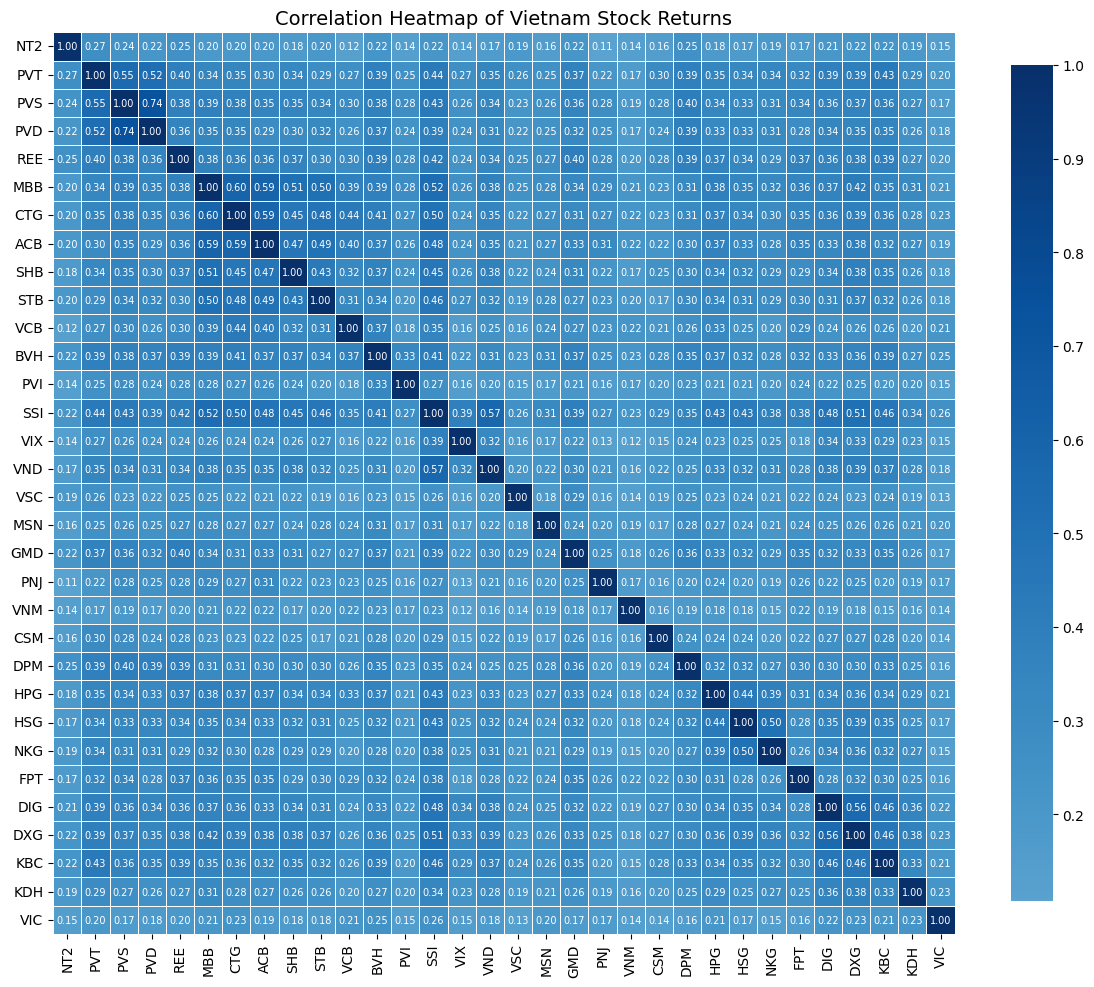

In [24]:
# EDA: Correlation
corr = df_vn_ret.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.9},
    annot_kws={"size": 7}
)

plt.title("Correlation Heatmap of Vietnam Stock Returns", fontsize=14)
#plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The assets that make our sample (as representative of systemically important sectors to proxy the Vietnamese market) do now show any negative correlation, which means that the market is directionally unified; in other words, stocks tend to move in the same direction as average, not providing much hedging opportunities. However, the full-sample correlation is moderate (0.15-0.55 mostly), suggesting Vietnamese market is anyway not fully-synchronized.

A rolling metric like the Absorption Ratio, which is part of our framework, can measure changes over time of this "market aggregation", to test whether assets tend to be more synchronzed in time of stress.

In [25]:
# EDA: Augmented Dickey Fuller Test (ADF) to check for stationarity
for c in df_vn_ret.columns:
  adf_n = ADF(df_vn_ret[c], trend="n", method="bic")# ADF Test without Drift and Trend
  print("Augmented Dickey Fuller (ADF) Stationarity Test (no drift, no trend) for {} stock returns:\n".format(c), adf_n)
  print('')

Augmented Dickey Fuller (ADF) Stationarity Test (no drift, no trend) for NT2 stock returns:
    Augmented Dickey-Fuller Results   
Test Statistic                -46.673
P-value                         0.000
Lags                                1
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.

Augmented Dickey Fuller (ADF) Stationarity Test (no drift, no trend) for PVT stock returns:
    Augmented Dickey-Fuller Results   
Test Statistic                -57.713
P-value                         0.000
Lags                                0
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.

Augmented Dickey Fuller (ADF) Stationarity Test (no drift, no trend) for P

All resturn series are (weakly) stationary.

In [26]:
# EDA: Analysis of rolling volatility (std), skewness, and (excess) kurtosis
window = 250
# Rolling volatility (std)
rolling_vol = df_vn_ret.rolling(window).std()
# Rolling skewness
rolling_skew = df_vn_ret.rolling(window).skew()
# Rolling kurtosis (this is already EXCESS kurtosis in pandas)
rolling_kurt = df_vn_ret.rolling(window).kurt()
#Cross-sectional averages
avg_vol = rolling_vol.mean(axis=1) * np.sqrt(250) #annualized
avg_skew = rolling_skew.mean(axis=1)
avg_kurt = rolling_kurt.mean(axis=1)

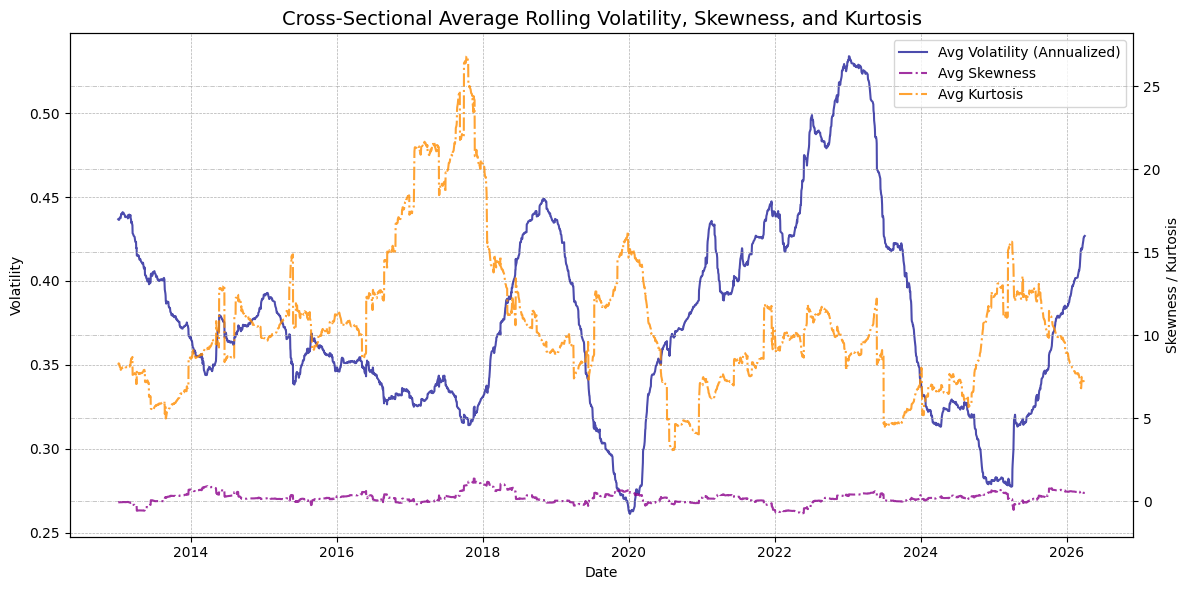

In [27]:
# Plot the cross-sectional average of rolling returns volatility, skewness, and kurtosis over time
fig, ax1 = plt.subplots(figsize=(12, 6))

# Volatility (left axis)
ax1.plot(avg_vol.index, avg_vol, linestyle='-', color='darkblue', label='Avg Volatility (Annualized)', alpha=0.7)
ax1.set_ylabel('Volatility')
ax1.set_title('Cross-Sectional Average Rolling Volatility, Skewness, and Kurtosis', fontsize=14)
plt.grid(True, linestyle='--', linewidth=.5)
plt.xlabel('Date')

# Second axis for skew/kurt (different scale)
ax2 = ax1.twinx()
ax2.plot(avg_skew.index, avg_skew, linestyle='-.', color='darkmagenta', label='Avg Skewness', alpha=0.8)
ax2.plot(avg_kurt.index, avg_kurt, linestyle='-.', color='darkorange', label='Avg Kurtosis', alpha=0.8)
ax2.set_ylabel('Skewness / Kurtosis')

# Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.grid(True, linestyle='-.', linewidth=.5)
plt.tight_layout()
plt.show()

In [28]:
# EDA: Descriptive Stats for trading volume data
df_vn_vol.describe()/1000

,NT2_volume,PVT_volume,PVS_volume,PVD_volume,REE_volume,MBB_volume,CTG_volume,ACB_volume,SHB_volume,STB_volume,...,DPM_volume,HPG_volume,HSG_volume,NKG_volume,FPT_volume,DIG_volume,DXG_volume,KBC_volume,KDH_volume,VIC_volume
count,3.552000,3.552000,3.552000,3.552000,3.552000,3.552000,3.552000,3.552000,3.552000,3.552000,...,3.552000,3.552000,3.552000,3.552000,3.552000,3.552000,3.552000,3.552000,3.552000,3.552000
mean,555.826495,2068.638668,4365.450427,3647.934347,847.180053,8082.246132,4730.685332,4104.838867,14562.147102,8977.967204,...,1932.216073,12651.138080,5304.098615,3352.866109,2008.344426,5636.796599,6236.473975,3989.743178,1201.610068,1789.627404
std,746.140099,2416.775723,4187.894845,3848.445311,684.107045,10457.898440,5074.867690,5446.392778,22571.396815,10955.646476,...,2494.283538,16877.483484,5860.551665,5098.035681,2925.998593,8866.832537,8063.559861,3950.975771,1906.436214,2559.570490
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,106.707500,521.390000,1401.136500,718.835000,379.145000,1185.755000,903.242500,340.105500,2538.316750,917.202500,...,444.087500,1217.722500,599.810000,96.877500,497.335000,455.605000,760.620000,1378.737500,101.505000,400.935000
50%,350.235000,1309.650000,2906.814000,2451.355000,655.600000,4638.995000,3162.045000,2238.986000,6607.121500,4894.505000,...,965.140000,5522.175000,3041.975000,546.405000,1124.900000,1332.525000,2943.015000,2695.195000,303.860000,1013.335000
75%,708.625000,2762.175000,6036.302500,5250.225000,1087.260000,10731.175000,6724.175000,5787.350000,16088.349500,13398.600000,...,2560.675000,19170.125000,8395.490000,5437.000000,2255.747500,7450.975000,8901.275000,5288.542500,1604.375000,2149.550000
max,10592.840000,29040.300000,31261.749000,32482.600000,5689.340000,117471.300000,38922.900000,72249.400000,249681.700000,105089.800000,...,39829.000000,215999.100000,43647.100000,48192.700000,47733.100000,128443.910000,70555.100000,35641.400000,21160.400000,28220.800000


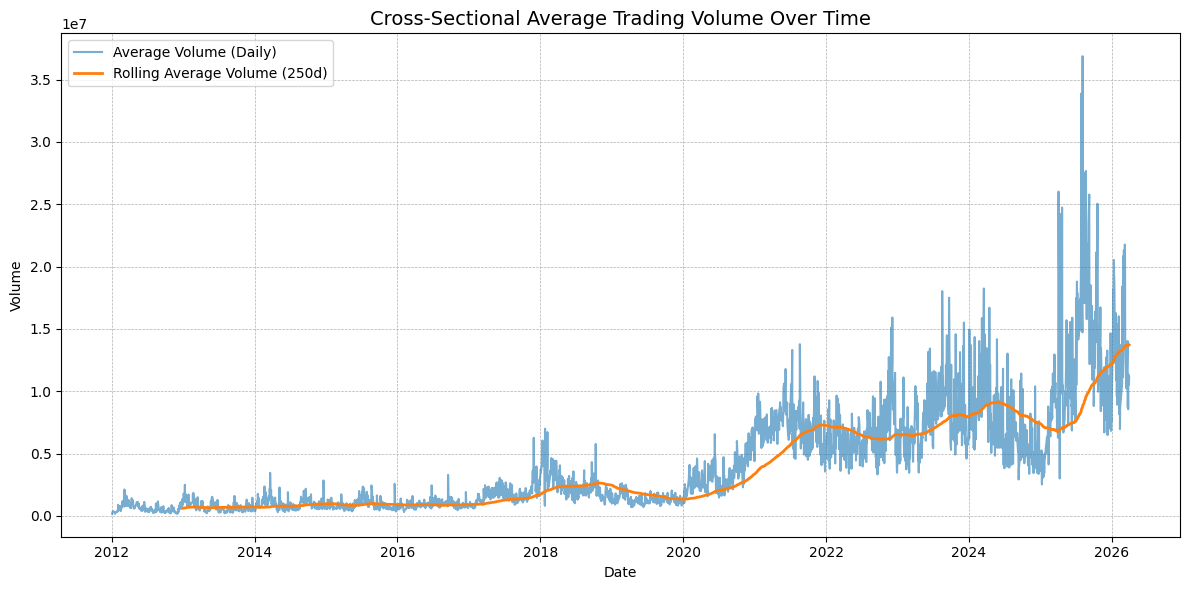

In [29]:
# EDA: Cross-sectional average trading volume over time
avg_volume = df_vn_vol.mean(axis=1)
# Rolling average (250d)
rolling_avg_volume = avg_volume.rolling(250).mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(avg_volume, label='Average Volume (Daily)', alpha=0.6)
plt.plot(rolling_avg_volume, label='Rolling Average Volume (250d)', linewidth=2)

plt.title('Cross-Sectional Average Trading Volume Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volume')

plt.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', linewidth=.5)
plt.show()

### 2.2. International Data